In [1]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5080


In [2]:
LR_FOLDER  = r'C:\Users\Azozi\Desktop\dataest\LR_new'
HR_FOLDER  = r'C:\Users\Azozi\Desktop\dataest\hr'
CKPT_DIR   = './checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

SCALE_FACTOR = 4
PATCH_SIZE   = 60
BATCH_SIZE   = 48
NUM_EPOCHS   = 50
LR_INIT      = 1e-4
TEST_RATIO   = 0.1

In [3]:
class SRDataset(Dataset):
    def __init__(self, lr_folder, hr_folder, patch_size=None, split='train', test_ratio=0.1, augment=False):
        valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        self.lr_images = sorted([f for f in os.listdir(lr_folder) if f.lower().endswith(valid_ext)])
        self.hr_images = sorted([f for f in os.listdir(hr_folder) if f.lower().endswith(valid_ext)])
        assert len(self.lr_images) == len(self.hr_images), 'LR and HR folders must match'
        self.lr_folder = lr_folder
        self.hr_folder = hr_folder
        self.patch_size = patch_size
        self.augment = augment
        self.to_tensor = transforms.ToTensor()

        n = len(self.lr_images)
        n_test = int(n * test_ratio)
        n_train = n - n_test

        if split == 'train':
            self.lr_images = self.lr_images[:n_train]
            self.hr_images = self.hr_images[:n_train]
        else:
            self.lr_images = self.lr_images[n_train:]
            self.hr_images = self.hr_images[n_train:]

        print(f'Caching {len(self.lr_images)} images into RAM ({split})...')
        self.lr_cache = []
        self.hr_cache = []
        for i, (lf, hf) in enumerate(zip(self.lr_images, self.hr_images)):
            self.lr_cache.append(Image.open(os.path.join(lr_folder, lf)).convert('RGB'))
            self.hr_cache.append(Image.open(os.path.join(hr_folder, hf)).convert('RGB'))
            if (i + 1) % 5000 == 0:
                print(f'  {i+1}/{len(self.lr_images)}')

    def __len__(self):
        return len(self.lr_images)

    def __getitem__(self, idx):
        lr = self.lr_cache[idx].copy()
        hr = self.hr_cache[idx].copy()

        if self.patch_size is not None:
            scale = SCALE_FACTOR
            lr_patch_size = self.patch_size
            hr_patch_size = self.patch_size * scale

            if lr.width < lr_patch_size or lr.height < lr_patch_size:
                new_w = max(lr.width,  lr_patch_size + 1)
                new_h = max(lr.height, lr_patch_size + 1)
                lr = lr.resize((new_w, new_h), Image.BICUBIC)
                hr = hr.resize((new_w * scale, new_h * scale), Image.BICUBIC)

            left = random.randint(0, lr.width  - lr_patch_size)
            top  = random.randint(0, lr.height - lr_patch_size)

            lr = lr.crop((left, top, left + lr_patch_size, top + lr_patch_size))
            hr = hr.crop((left * scale, top * scale,
                          left * scale + hr_patch_size, top * scale + hr_patch_size))

        if self.augment:
            if random.random() > 0.5:
                lr = lr.transpose(Image.FLIP_LEFT_RIGHT)
                hr = hr.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                lr = lr.transpose(Image.FLIP_TOP_BOTTOM)
                hr = hr.transpose(Image.FLIP_TOP_BOTTOM)
            angle = random.choice([0, 90, 180, 270])
            if angle != 0:
                lr = lr.rotate(angle)
                hr = hr.rotate(angle)

        return self.to_tensor(lr), self.to_tensor(hr)

In [4]:
train_dataset = SRDataset(LR_FOLDER, HR_FOLDER, patch_size=PATCH_SIZE, split='train', test_ratio=TEST_RATIO, augment=True)
test_dataset = SRDataset(LR_FOLDER, HR_FOLDER, patch_size=PATCH_SIZE, split='test',  test_ratio=TEST_RATIO, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Caching 51744 images into RAM (train)...
  5000/51744
  10000/51744
  15000/51744
  20000/51744
  25000/51744
  30000/51744
  35000/51744
  40000/51744
  45000/51744
  50000/51744
Caching 5749 images into RAM (test)...
  5000/5749


In [5]:
class ESPCN(nn.Module):
    def __init__(self, scale_factor=4, in_channels=3):
        super().__init__()
        self.scale = scale_factor
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, in_channels * (scale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.act1 = nn.PReLU(num_parameters=64)
        self.act2 = nn.PReLU(num_parameters=32)
        self._init_weights()

    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.act2(self.conv2(x))
        x = self.pixel_shuffle(self.conv3(x))
        return torch.clamp(x, 0.0, 1.0)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.orthogonal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

model = ESPCN(scale_factor=SCALE_FACTOR, in_channels=3).to(DEVICE)
print('Total parameters    :', sum(p.numel() for p in model.parameters()))
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))


Total parameters    : 37296
Trainable parameters: 37296


In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [7]:
def compute_psnr(pred, target):
    mse = torch.mean((pred.float() - target.float()) ** 2)
    if mse == 0:
        return 100.0
    return (10 * torch.log10(1.0 / mse)).item()

def compute_ssim(pred, target):
    pred = pred.float().unsqueeze(0)
    target = target.float().unsqueeze(0)
    mu1 = torch.nn.functional.avg_pool2d(pred,   3, 1, 1)
    mu2 = torch.nn.functional.avg_pool2d(target, 3, 1, 1)
    mu1_sq  = mu1 ** 2
    mu2_sq  = mu2 ** 2
    mu1_mu2 = mu1 * mu2
    sigma1_sq = torch.nn.functional.avg_pool2d(pred   ** 2, 3, 1, 1) - mu1_sq
    sigma2_sq = torch.nn.functional.avg_pool2d(target ** 2, 3, 1, 1) - mu2_sq
    sigma12 = torch.nn.functional.avg_pool2d(pred * target, 3, 1, 1) - mu1_mu2
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean().item()

In [8]:
import math
from datetime import datetime

scaler = torch.amp.GradScaler('cuda')

history = {
    'train_loss': [],
    'test_psnr' : [],
    'test_ssim' : [],
    'lr'        : []
}

best_psnr  = 0.0
best_epoch = 0
CKPT_PATH  = os.path.join(CKPT_DIR, 'espcn_best.pth')

print('Training for', NUM_EPOCHS, 'epochs on', DEVICE)
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    model.train()
    epoch_loss = 0.0

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):
        lr_batch = lr_batch.to(DEVICE, non_blocking=True)
        hr_batch = hr_batch.to(DEVICE, non_blocking=True)

        sr_batch = model(lr_batch)

        h_sr, w_sr = sr_batch.size(2), sr_batch.size(3)
        h_hr, w_hr = hr_batch.size(2), hr_batch.size(3)
        top  = (h_hr - h_sr) // 2
        left = (w_hr - w_sr) // 2
        hr_cropped = hr_batch[:, :, top:top+h_sr, left:left+w_sr]

        loss = criterion(sr_batch, hr_cropped)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

        if batch_idx % 50 == 0:
            current_clock = datetime.now().strftime('%H:%M:%S')
            with torch.no_grad():
                mse = torch.mean((sr_batch - hr_cropped) ** 2)
                quick_psnr = 10 * math.log10(1 / mse.item()) if mse.item() > 0 else 100
            print(f'[{current_clock}] Epoch {epoch} | Batch {batch_idx} | Loss: {loss.item():.4f} | Quick PSNR: {quick_psnr:.2f}dB')

    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)

    model.eval()
    test_psnr = 0.0
    test_ssim = 0.0

    with torch.no_grad():
        for lr_batch, hr_batch in tqdm(test_loader, desc=f'Epoch {epoch:3d} Test', leave=False):
            lr_batch = lr_batch.to(DEVICE, non_blocking=True)
            hr_batch = hr_batch.to(DEVICE, non_blocking=True)
            sr_batch = model(lr_batch)

            h_sr, w_sr = sr_batch.size(2), sr_batch.size(3)
            h_hr, w_hr = hr_batch.size(2), hr_batch.size(3)
            top  = (h_hr - h_sr) // 2
            left = (w_hr - w_sr) // 2
            hr_cropped = hr_batch[:, :, top:top+h_sr, left:left+w_sr]

            for i in range(sr_batch.size(0)):
                test_psnr += compute_psnr(sr_batch[i], hr_cropped[i])
                test_ssim += compute_ssim(sr_batch[i], hr_cropped[i])

    test_psnr /= len(test_dataset)
    test_ssim /= len(test_dataset)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(avg_loss)
    history['test_psnr'].append(test_psnr)
    history['test_ssim'].append(test_ssim)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    marker  = ''
    if test_psnr > best_psnr:
        best_psnr  = test_psnr
        best_epoch = epoch
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'test_psnr'  : test_psnr,
            'test_ssim'  : test_ssim,
        }, CKPT_PATH)
        marker = ' <-- NEW BEST!'

    print('\n' + '=' * 40)
    print(f'EPOCH [{epoch}/{NUM_EPOCHS}] COMPLETE')
    print(f'Average Loss : {avg_loss:.6f}')
    print(f'Test PSNR    : {test_psnr:.2f} dB')
    print(f'Test SSIM    : {test_ssim:.4f}')
    print(f'LR           : {current_lr:.2e}')
    print(f'Time         : {elapsed:.1f}s' + marker)
    print('=' * 40 + '\n')

print('-' * 70)
print('Training done. Best epoch:', best_epoch, '  PSNR:', round(best_psnr, 2), 'dB')


Training for 50 epochs on cuda
----------------------------------------------------------------------
[18:00:13] Epoch 1 | Batch 0 | Loss: 0.1763 | Quick PSNR: 7.54dB
[18:00:15] Epoch 1 | Batch 50 | Loss: 0.0485 | Quick PSNR: 13.14dB
[18:00:16] Epoch 1 | Batch 100 | Loss: 0.0258 | Quick PSNR: 15.88dB
[18:00:17] Epoch 1 | Batch 150 | Loss: 0.0302 | Quick PSNR: 15.19dB
[18:00:19] Epoch 1 | Batch 200 | Loss: 0.0185 | Quick PSNR: 17.32dB
[18:00:20] Epoch 1 | Batch 250 | Loss: 0.0159 | Quick PSNR: 17.97dB
[18:00:21] Epoch 1 | Batch 300 | Loss: 0.0132 | Quick PSNR: 18.78dB
[18:00:23] Epoch 1 | Batch 350 | Loss: 0.0144 | Quick PSNR: 18.43dB
[18:00:24] Epoch 1 | Batch 400 | Loss: 0.0121 | Quick PSNR: 19.18dB
[18:00:25] Epoch 1 | Batch 450 | Loss: 0.0110 | Quick PSNR: 19.59dB
[18:00:27] Epoch 1 | Batch 500 | Loss: 0.0093 | Quick PSNR: 20.31dB
[18:00:28] Epoch 1 | Batch 550 | Loss: 0.0048 | Quick PSNR: 23.20dB
[18:00:29] Epoch 1 | Batch 600 | Loss: 0.0046 | Quick PSNR: 23.39dB
[18:00:31] Epoch 1


EPOCH [1/50] COMPLETE
Average Loss : 0.014042
Test PSNR    : 24.39 dB
Test SSIM    : 0.5270
LR           : 1.00e-04
Time         : 38.3s <-- NEW BEST!

[18:00:51] Epoch 2 | Batch 0 | Loss: 0.0033 | Quick PSNR: 24.79dB
[18:00:52] Epoch 2 | Batch 50 | Loss: 0.0028 | Quick PSNR: 25.58dB
[18:00:54] Epoch 2 | Batch 100 | Loss: 0.0027 | Quick PSNR: 25.64dB
[18:00:55] Epoch 2 | Batch 150 | Loss: 0.0022 | Quick PSNR: 26.59dB
[18:00:56] Epoch 2 | Batch 200 | Loss: 0.0021 | Quick PSNR: 26.71dB
[18:00:58] Epoch 2 | Batch 250 | Loss: 0.0023 | Quick PSNR: 26.40dB
[18:00:59] Epoch 2 | Batch 300 | Loss: 0.0021 | Quick PSNR: 26.69dB
[18:01:00] Epoch 2 | Batch 350 | Loss: 0.0021 | Quick PSNR: 26.70dB
[18:01:02] Epoch 2 | Batch 400 | Loss: 0.0024 | Quick PSNR: 26.12dB
[18:01:03] Epoch 2 | Batch 450 | Loss: 0.0021 | Quick PSNR: 26.87dB
[18:01:04] Epoch 2 | Batch 500 | Loss: 0.0021 | Quick PSNR: 26.69dB
[18:01:06] Epoch 2 | Batch 550 | Loss: 0.0015 | Quick PSNR: 28.24dB
[18:01:07] Epoch 2 | Batch 600 | L


EPOCH [2/50] COMPLETE
Average Loss : 0.002112
Test PSNR    : 26.19 dB
Test SSIM    : 0.6277
LR           : 1.00e-04
Time         : 38.8s <-- NEW BEST!

[18:01:30] Epoch 3 | Batch 0 | Loss: 0.0019 | Quick PSNR: 27.22dB
[18:01:31] Epoch 3 | Batch 50 | Loss: 0.0016 | Quick PSNR: 28.03dB
[18:01:33] Epoch 3 | Batch 100 | Loss: 0.0016 | Quick PSNR: 27.86dB
[18:01:34] Epoch 3 | Batch 150 | Loss: 0.0019 | Quick PSNR: 27.27dB
[18:01:35] Epoch 3 | Batch 200 | Loss: 0.0017 | Quick PSNR: 27.66dB
[18:01:37] Epoch 3 | Batch 250 | Loss: 0.0016 | Quick PSNR: 27.98dB
[18:01:38] Epoch 3 | Batch 300 | Loss: 0.0017 | Quick PSNR: 27.74dB
[18:01:39] Epoch 3 | Batch 350 | Loss: 0.0016 | Quick PSNR: 28.02dB
[18:01:41] Epoch 3 | Batch 400 | Loss: 0.0017 | Quick PSNR: 27.65dB
[18:01:42] Epoch 3 | Batch 450 | Loss: 0.0020 | Quick PSNR: 27.07dB
[18:01:44] Epoch 3 | Batch 500 | Loss: 0.0018 | Quick PSNR: 27.55dB
[18:01:45] Epoch 3 | Batch 550 | Loss: 0.0024 | Quick PSNR: 26.24dB
[18:01:46] Epoch 3 | Batch 600 | L


EPOCH [3/50] COMPLETE
Average Loss : 0.001583
Test PSNR    : 26.88 dB
Test SSIM    : 0.6646
LR           : 1.00e-04
Time         : 39.3s <-- NEW BEST!

[18:02:09] Epoch 4 | Batch 0 | Loss: 0.0015 | Quick PSNR: 28.34dB
[18:02:11] Epoch 4 | Batch 50 | Loss: 0.0015 | Quick PSNR: 28.32dB
[18:02:12] Epoch 4 | Batch 100 | Loss: 0.0014 | Quick PSNR: 28.67dB
[18:02:13] Epoch 4 | Batch 150 | Loss: 0.0018 | Quick PSNR: 27.44dB
[18:02:15] Epoch 4 | Batch 200 | Loss: 0.0016 | Quick PSNR: 28.01dB
[18:02:16] Epoch 4 | Batch 250 | Loss: 0.0014 | Quick PSNR: 28.56dB
[18:02:18] Epoch 4 | Batch 300 | Loss: 0.0015 | Quick PSNR: 28.27dB
[18:02:19] Epoch 4 | Batch 350 | Loss: 0.0014 | Quick PSNR: 28.46dB
[18:02:21] Epoch 4 | Batch 400 | Loss: 0.0013 | Quick PSNR: 29.00dB
[18:02:22] Epoch 4 | Batch 450 | Loss: 0.0014 | Quick PSNR: 28.63dB
[18:02:24] Epoch 4 | Batch 500 | Loss: 0.0017 | Quick PSNR: 27.60dB
[18:02:25] Epoch 4 | Batch 550 | Loss: 0.0016 | Quick PSNR: 28.01dB
[18:02:26] Epoch 4 | Batch 600 | L


EPOCH [4/50] COMPLETE
Average Loss : 0.001412
Test PSNR    : 27.16 dB
Test SSIM    : 0.6794
LR           : 1.00e-04
Time         : 40.5s <-- NEW BEST!

[18:02:50] Epoch 5 | Batch 0 | Loss: 0.0015 | Quick PSNR: 28.32dB
[18:02:51] Epoch 5 | Batch 50 | Loss: 0.0015 | Quick PSNR: 28.38dB
[18:02:53] Epoch 5 | Batch 100 | Loss: 0.0018 | Quick PSNR: 27.36dB
[18:02:54] Epoch 5 | Batch 150 | Loss: 0.0011 | Quick PSNR: 29.45dB
[18:02:55] Epoch 5 | Batch 200 | Loss: 0.0013 | Quick PSNR: 28.98dB
[18:02:57] Epoch 5 | Batch 250 | Loss: 0.0013 | Quick PSNR: 28.78dB
[18:02:58] Epoch 5 | Batch 300 | Loss: 0.0012 | Quick PSNR: 29.24dB
[18:03:00] Epoch 5 | Batch 350 | Loss: 0.0017 | Quick PSNR: 27.79dB
[18:03:01] Epoch 5 | Batch 400 | Loss: 0.0011 | Quick PSNR: 29.45dB
[18:03:03] Epoch 5 | Batch 450 | Loss: 0.0015 | Quick PSNR: 28.32dB
[18:03:04] Epoch 5 | Batch 500 | Loss: 0.0014 | Quick PSNR: 28.40dB
[18:03:05] Epoch 5 | Batch 550 | Loss: 0.0016 | Quick PSNR: 27.93dB
[18:03:07] Epoch 5 | Batch 600 | L

...


EPOCH [46/50] COMPLETE
Average Loss : 0.001156
Test PSNR    : 27.84 dB
Test SSIM    : 0.7048
LR           : 1.00e-04
Time         : 42.7s

[18:31:44] Epoch 47 | Batch 0 | Loss: 0.0011 | Quick PSNR: 29.73dB
[18:31:46] Epoch 47 | Batch 50 | Loss: 0.0012 | Quick PSNR: 29.05dB
[18:31:47] Epoch 47 | Batch 100 | Loss: 0.0014 | Quick PSNR: 28.55dB
[18:31:49] Epoch 47 | Batch 150 | Loss: 0.0014 | Quick PSNR: 28.43dB
[18:31:50] Epoch 47 | Batch 200 | Loss: 0.0012 | Quick PSNR: 29.21dB
[18:31:52] Epoch 47 | Batch 250 | Loss: 0.0011 | Quick PSNR: 29.45dB
[18:31:53] Epoch 47 | Batch 300 | Loss: 0.0009 | Quick PSNR: 30.37dB
[18:31:55] Epoch 47 | Batch 350 | Loss: 0.0013 | Quick PSNR: 28.78dB
[18:31:56] Epoch 47 | Batch 400 | Loss: 0.0011 | Quick PSNR: 29.51dB
[18:31:58] Epoch 47 | Batch 450 | Loss: 0.0010 | Quick PSNR: 30.03dB
[18:31:59] Epoch 47 | Batch 500 | Loss: 0.0010 | Quick PSNR: 29.85dB
[18:32:01] Epoch 47 | Batch 550 | Loss: 0.0009 | Quick PSNR: 30.62dB
[18:32:02] Epoch 47 | Batch 600 | L


EPOCH [47/50] COMPLETE
Average Loss : 0.001154
Test PSNR    : 27.86 dB
Test SSIM    : 0.7048
LR           : 1.00e-04
Time         : 42.8s <-- NEW BEST!

[18:32:27] Epoch 48 | Batch 0 | Loss: 0.0012 | Quick PSNR: 29.38dB
[18:32:28] Epoch 48 | Batch 50 | Loss: 0.0011 | Quick PSNR: 29.49dB
[18:32:30] Epoch 48 | Batch 100 | Loss: 0.0012 | Quick PSNR: 29.24dB
[18:32:31] Epoch 48 | Batch 150 | Loss: 0.0011 | Quick PSNR: 29.41dB
[18:32:33] Epoch 48 | Batch 200 | Loss: 0.0014 | Quick PSNR: 28.46dB
[18:32:35] Epoch 48 | Batch 250 | Loss: 0.0009 | Quick PSNR: 30.43dB
[18:32:36] Epoch 48 | Batch 300 | Loss: 0.0012 | Quick PSNR: 29.25dB
[18:32:38] Epoch 48 | Batch 350 | Loss: 0.0012 | Quick PSNR: 29.09dB
[18:32:39] Epoch 48 | Batch 400 | Loss: 0.0010 | Quick PSNR: 29.81dB
[18:32:41] Epoch 48 | Batch 450 | Loss: 0.0014 | Quick PSNR: 28.50dB
[18:32:43] Epoch 48 | Batch 500 | Loss: 0.0013 | Quick PSNR: 28.87dB
[18:32:44] Epoch 48 | Batch 550 | Loss: 0.0010 | Quick PSNR: 30.07dB
[18:32:46] Epoch 48 |


EPOCH [48/50] COMPLETE
Average Loss : 0.001154
Test PSNR    : 27.79 dB
Test SSIM    : 0.7047
LR           : 1.00e-04
Time         : 43.2s

[18:33:10] Epoch 49 | Batch 0 | Loss: 0.0013 | Quick PSNR: 28.87dB
[18:33:12] Epoch 49 | Batch 50 | Loss: 0.0011 | Quick PSNR: 29.47dB
[18:33:13] Epoch 49 | Batch 100 | Loss: 0.0011 | Quick PSNR: 29.73dB
[18:33:15] Epoch 49 | Batch 150 | Loss: 0.0011 | Quick PSNR: 29.60dB
[18:33:16] Epoch 49 | Batch 200 | Loss: 0.0012 | Quick PSNR: 29.33dB
[18:33:18] Epoch 49 | Batch 250 | Loss: 0.0011 | Quick PSNR: 29.77dB
[18:33:19] Epoch 49 | Batch 300 | Loss: 0.0008 | Quick PSNR: 30.79dB
[18:33:21] Epoch 49 | Batch 350 | Loss: 0.0011 | Quick PSNR: 29.49dB
[18:33:22] Epoch 49 | Batch 400 | Loss: 0.0015 | Quick PSNR: 28.27dB
[18:33:24] Epoch 49 | Batch 450 | Loss: 0.0013 | Quick PSNR: 28.79dB
[18:33:25] Epoch 49 | Batch 500 | Loss: 0.0010 | Quick PSNR: 30.15dB
[18:33:27] Epoch 49 | Batch 550 | Loss: 0.0009 | Quick PSNR: 30.31dB
[18:33:28] Epoch 49 | Batch 600 | L


EPOCH [49/50] COMPLETE
Average Loss : 0.001153
Test PSNR    : 27.85 dB
Test SSIM    : 0.7049
LR           : 1.00e-04
Time         : 42.7s

[18:33:53] Epoch 50 | Batch 0 | Loss: 0.0010 | Quick PSNR: 29.97dB
[18:33:54] Epoch 50 | Batch 50 | Loss: 0.0011 | Quick PSNR: 29.55dB
[18:33:56] Epoch 50 | Batch 100 | Loss: 0.0010 | Quick PSNR: 29.95dB
[18:33:57] Epoch 50 | Batch 150 | Loss: 0.0011 | Quick PSNR: 29.77dB
[18:33:59] Epoch 50 | Batch 200 | Loss: 0.0010 | Quick PSNR: 30.01dB
[18:34:00] Epoch 50 | Batch 250 | Loss: 0.0011 | Quick PSNR: 29.58dB
[18:34:02] Epoch 50 | Batch 300 | Loss: 0.0013 | Quick PSNR: 29.01dB
[18:34:03] Epoch 50 | Batch 350 | Loss: 0.0011 | Quick PSNR: 29.41dB
[18:34:05] Epoch 50 | Batch 400 | Loss: 0.0010 | Quick PSNR: 30.19dB
[18:34:06] Epoch 50 | Batch 450 | Loss: 0.0012 | Quick PSNR: 29.28dB
[18:34:08] Epoch 50 | Batch 500 | Loss: 0.0014 | Quick PSNR: 28.46dB
[18:34:10] Epoch 50 | Batch 550 | Loss: 0.0010 | Quick PSNR: 29.96dB
[18:34:11] Epoch 50 | Batch 600 | L


EPOCH [50/50] COMPLETE
Average Loss : 0.001152
Test PSNR    : 27.86 dB
Test SSIM    : 0.7050
LR           : 1.00e-04
Time         : 42.5s <-- NEW BEST!

----------------------------------------------------------------------
Training done. Best epoch: 50   PSNR: 27.86 dB


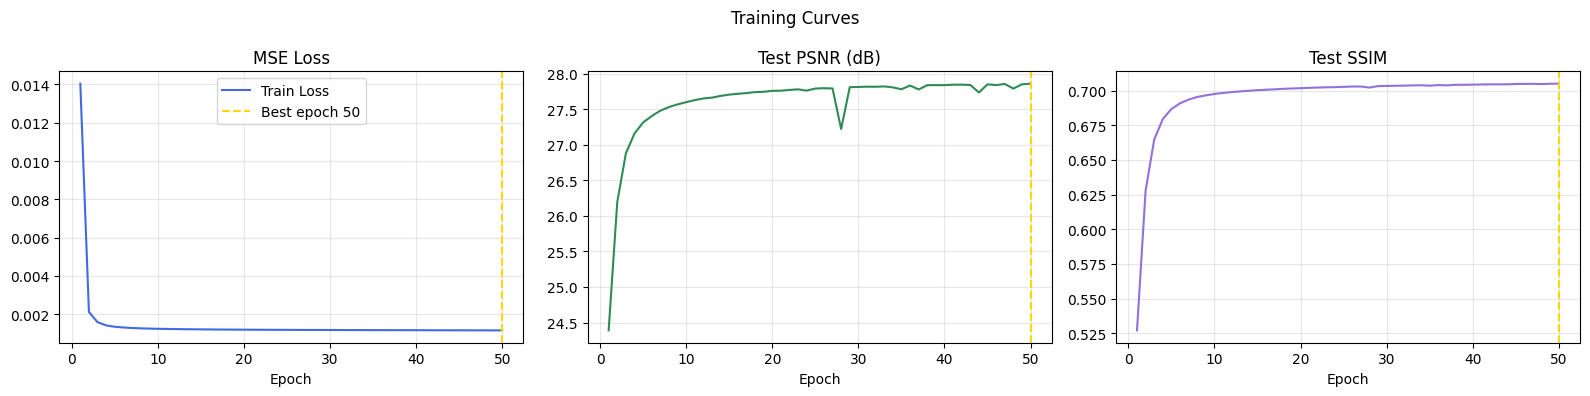

In [9]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].axvline(best_epoch, linestyle='--', color='gold', label='Best epoch ' + str(best_epoch))
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['test_psnr'], color='seagreen')
axes[1].axvline(best_epoch, linestyle='--', color='gold')
axes[1].set_title('Test PSNR (dB)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['test_ssim'], color='mediumpurple')
axes[2].axvline(best_epoch, linestyle='--', color='gold')
axes[2].set_title('Test SSIM')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Curves')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'training_curves.png'), dpi=150)
plt.show()


In [10]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print('Loaded checkpoint from epoch', ckpt['epoch'], '  test PSNR:', round(ckpt['test_psnr'], 2), 'dB')

test_psnr_list    = []
test_ssim_list    = []
bicubic_psnr_list = []
bicubic_ssim_list = []

with torch.no_grad():
    for lr_img, hr_img in tqdm(test_loader, desc='Testing'):
        lr_img = lr_img.to(DEVICE)
        hr_img = hr_img.to(DEVICE)

        with torch.amp.autocast('cuda'):
            sr_img = model(lr_img)

        test_psnr_list.append(compute_psnr(sr_img[0], hr_img[0]))
        test_ssim_list.append(compute_ssim(sr_img[0], hr_img[0]))

        h, w = hr_img.shape[-2], hr_img.shape[-1]
        bicubic = torch.nn.functional.interpolate(
            lr_img, size=(h, w), mode='bicubic', align_corners=False
        ).clamp(0, 1)
        bicubic_psnr_list.append(compute_psnr(bicubic[0], hr_img[0]))
        bicubic_ssim_list.append(compute_ssim(bicubic[0], hr_img[0]))

print('\nTest Results')
print('=' * 45)
print(f'  ESPCN   PSNR : {np.mean(test_psnr_list):.2f} +/- {np.std(test_psnr_list):.2f} dB')
print(f'  ESPCN   SSIM : {np.mean(test_ssim_list):.4f} +/- {np.std(test_ssim_list):.4f}')
print('-' * 45)
print(f'  Bicubic PSNR : {np.mean(bicubic_psnr_list):.2f} +/- {np.std(bicubic_psnr_list):.2f} dB')
print(f'  Bicubic SSIM : {np.mean(bicubic_ssim_list):.4f} +/- {np.std(bicubic_ssim_list):.4f}')
print('=' * 45)
print(f'  PSNR gain over Bicubic: +{np.mean(test_psnr_list) - np.mean(bicubic_psnr_list):.2f} dB')


Loaded checkpoint from epoch 50   test PSNR: 27.86 dB


Testing: 100%|██████████| 5749/5749 [00:15<00:00, 373.40it/s]


Test Results
  ESPCN   PSNR : 27.86 +/- 4.32 dB
  ESPCN   SSIM : 0.7050 +/- 0.1219
---------------------------------------------
  Bicubic PSNR : 27.17 +/- 4.34 dB
  Bicubic SSIM : 0.6808 +/- 0.1337
  PSNR gain over Bicubic: +0.69 dB


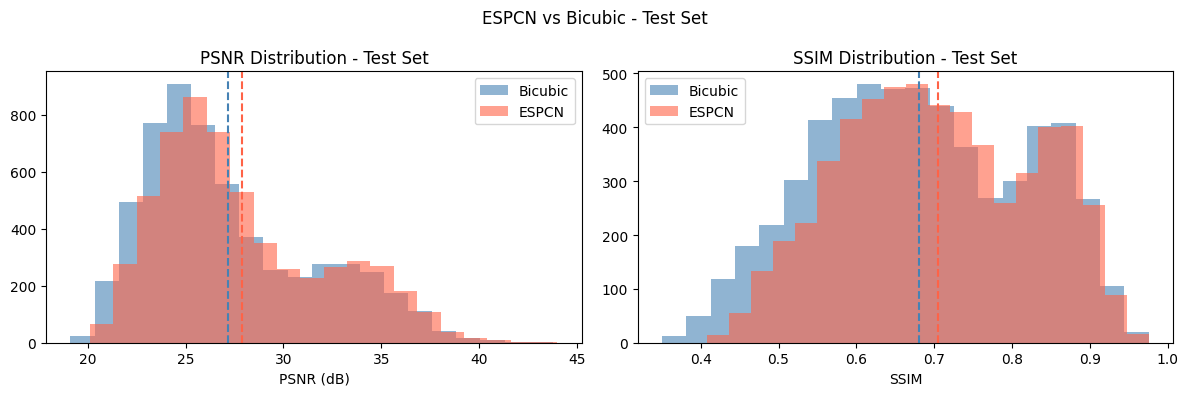

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(bicubic_psnr_list, bins=20, alpha=0.6, color='steelblue', label='Bicubic')
axes[0].hist(test_psnr_list,    bins=20, alpha=0.6, color='tomato',    label='ESPCN')
axes[0].axvline(np.mean(bicubic_psnr_list), color='steelblue', linestyle='--')
axes[0].axvline(np.mean(test_psnr_list),    color='tomato',    linestyle='--')
axes[0].set_title('PSNR Distribution - Test Set')
axes[0].set_xlabel('PSNR (dB)')
axes[0].legend()

axes[1].hist(bicubic_ssim_list, bins=20, alpha=0.6, color='steelblue', label='Bicubic')
axes[1].hist(test_ssim_list,    bins=20, alpha=0.6, color='tomato',    label='ESPCN')
axes[1].axvline(np.mean(bicubic_ssim_list), color='steelblue', linestyle='--')
axes[1].axvline(np.mean(test_ssim_list),    color='tomato',    linestyle='--')
axes[1].set_title('SSIM Distribution - Test Set')
axes[1].set_xlabel('SSIM')
axes[1].legend()

plt.suptitle('ESPCN vs Bicubic - Test Set')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'metric_distributions.png'), dpi=150)
plt.show()

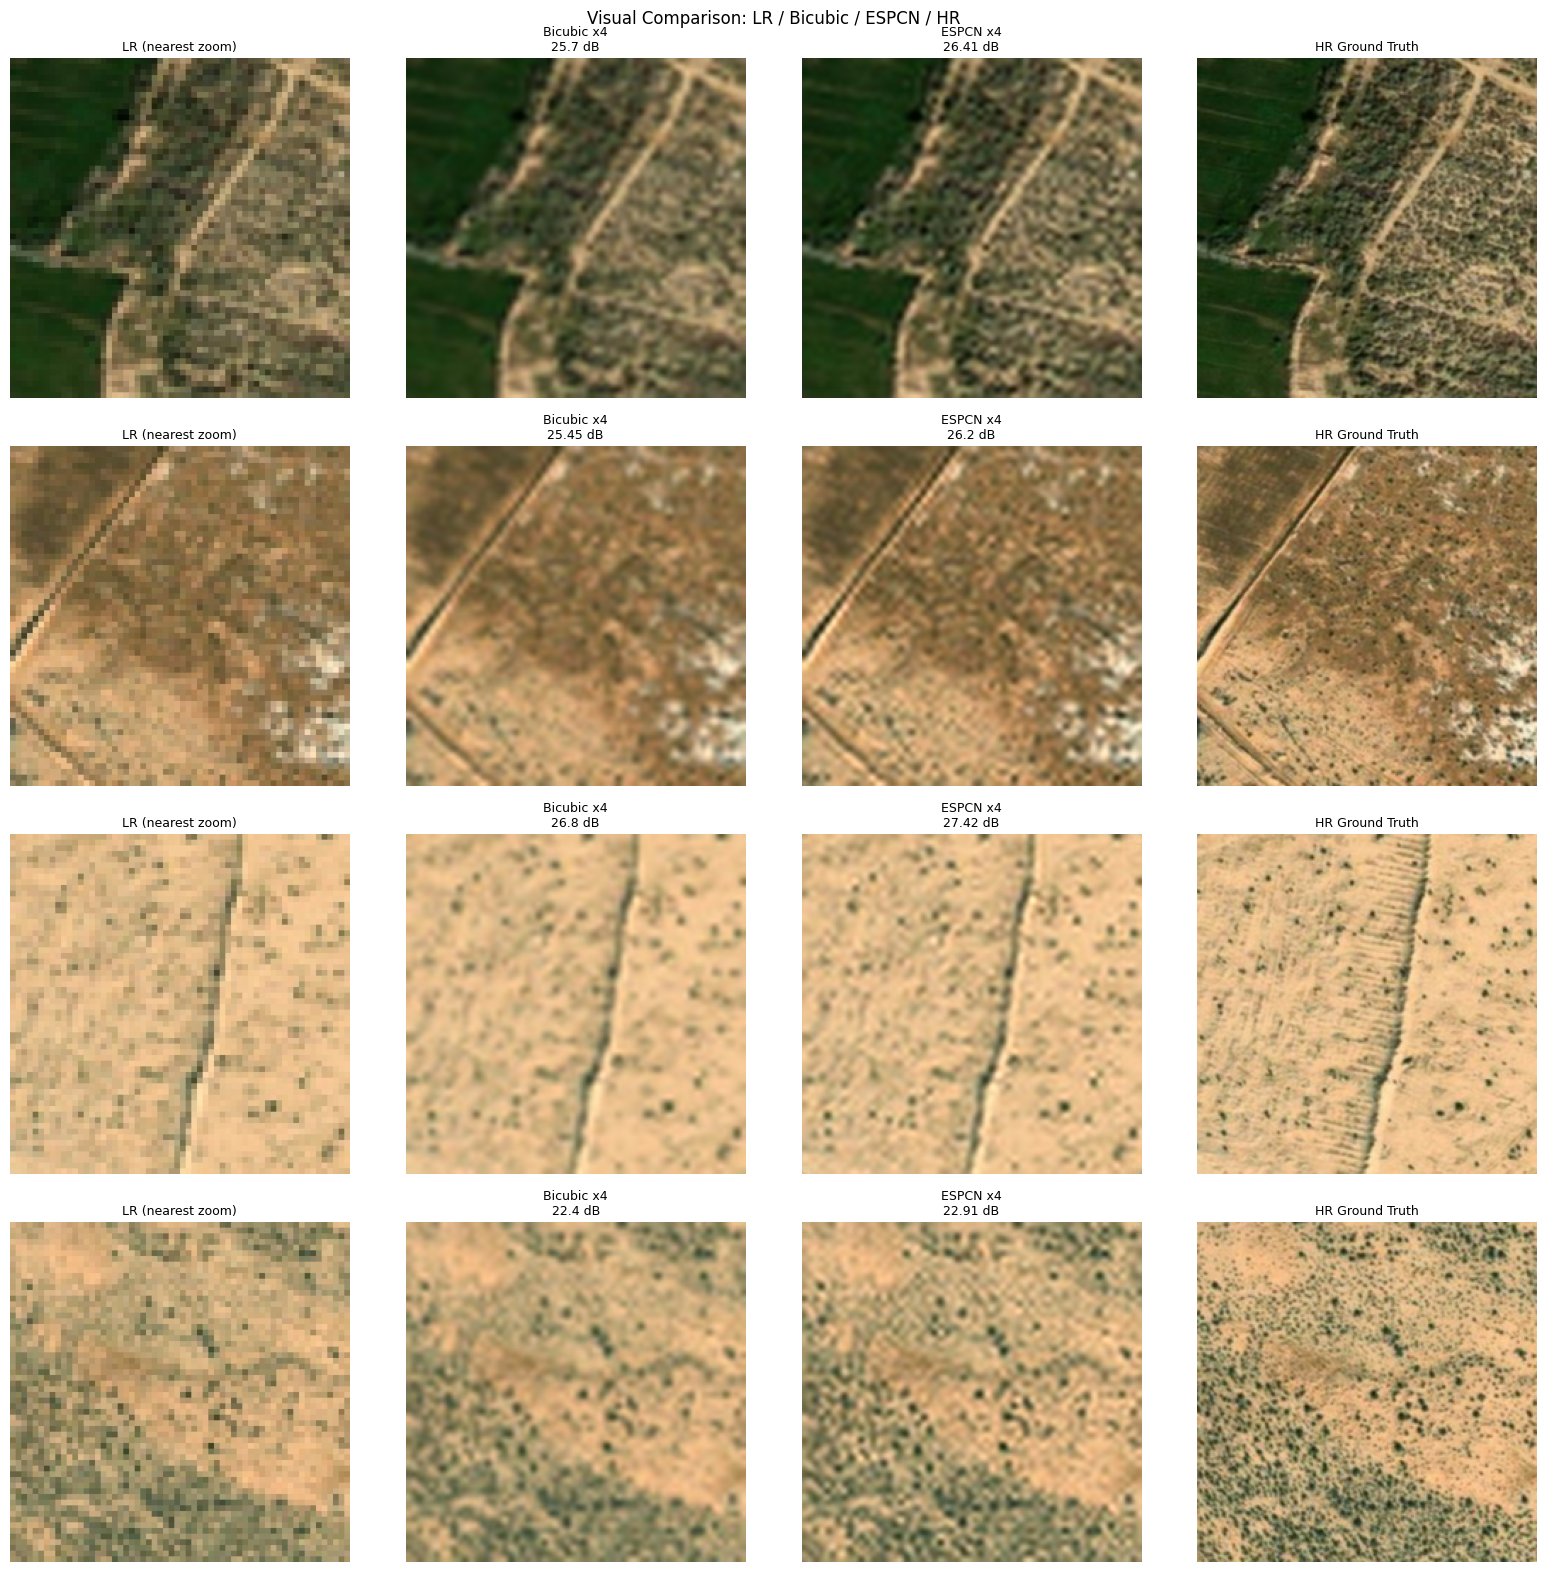

In [12]:
def visualise_results(model, dataset, n=4):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    model.eval()
    fig, axes = plt.subplots(len(indices), 4, figsize=(16, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes[None, :]

    col_titles = [
        'LR (nearest zoom)',
        'Bicubic x' + str(SCALE_FACTOR),
        'ESPCN x' + str(SCALE_FACTOR),
        'HR Ground Truth'
    ]

    for row, idx in enumerate(indices):
        lr_t, hr_t = dataset[idx]
        lr_in = lr_t.unsqueeze(0).to(DEVICE)
        h, w  = hr_t.shape[-2], hr_t.shape[-1]

        with torch.no_grad():
            sr_t = model(lr_in)[0].cpu()

        bicubic_t = torch.nn.functional.interpolate(
            lr_in, size=(h, w), mode='bicubic', align_corners=False
        )[0].cpu().clamp(0, 1)

        lr_zoom = torch.nn.functional.interpolate(
            lr_in, size=(h, w), mode='nearest'
        )[0].cpu()

        imgs  = [lr_zoom, bicubic_t, sr_t, hr_t]
        psnrs = [None, compute_psnr(bicubic_t, hr_t), compute_psnr(sr_t, hr_t), None]

        for col, (img, psnr) in enumerate(zip(imgs, psnrs)):
            axes[row, col].imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
            title = col_titles[col]
            if psnr is not None:
                title += '\n' + str(round(psnr, 2)) + ' dB'
            axes[row, col].set_title(title, fontsize=9)
            axes[row, col].axis('off')

    plt.suptitle('Visual Comparison: LR / Bicubic / ESPCN / HR')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'visual_comparison.png'), dpi=150)
    plt.show()

visualise_results(model, test_dataset)

Saved SR image to: ./sr_output.png


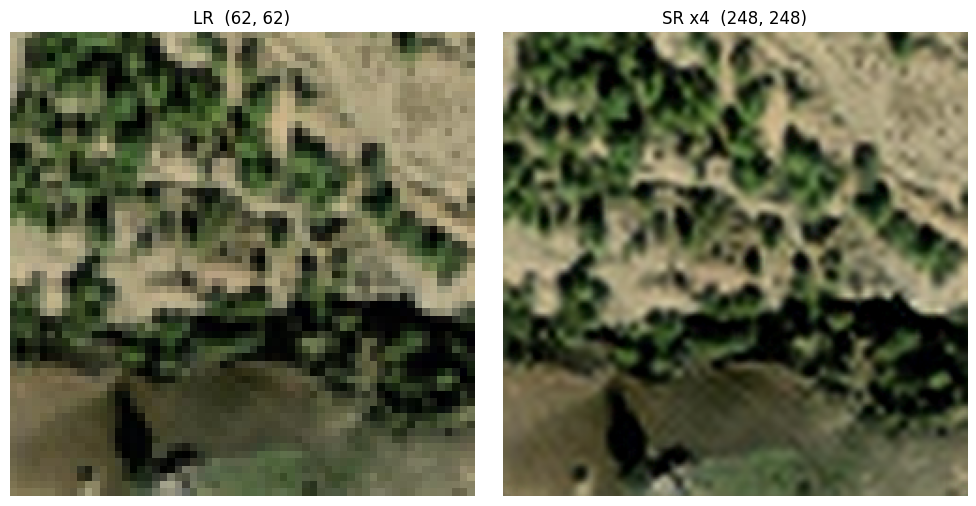

In [13]:
def super_resolve(model, lr_image_path, save_path=None):
    model.eval()
    to_tensor = transforms.ToTensor()
    to_pil    = transforms.ToPILImage()

    lr_pil = Image.open(lr_image_path).convert('RGB')
    lr_t   = to_tensor(lr_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        sr_t = model(lr_t)[0].cpu().clamp(0, 1)

    sr_pil = to_pil(sr_t)

    if save_path:
        sr_pil.save(save_path)
        print('Saved SR image to:', save_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(lr_pil)
    axes[0].set_title('LR  ' + str(lr_pil.size))
    axes[0].axis('off')
    axes[1].imshow(sr_pil)
    axes[1].set_title('SR x' + str(SCALE_FACTOR) + '  ' + str(sr_pil.size))
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    return sr_pil

files = os.listdir(LR_FOLDER)
sr = super_resolve(model, os.path.join(LR_FOLDER, files[0]), save_path='./sr_output.png')